In [1]:
import sys
import os
import torch
import torch.utils.data as data
import torch.nn as nn

sys.path.append(os.path.abspath('../'))

from neuro_fuzzy_toolbox import ANFIS, Hybrid_learning_algorithm, rule_reduced_SONFIS, EarlyStopping, get_measures

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [3]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Regression

## Data

In [4]:
def z(x, y):
  return ((3) * ((1-x)**2) * (np.exp(-(x**2)-((y+1)**2))) - (10) * ((x/5)-(x**3)-(y**5)) * (np.exp(-(x**2)-(y**2))) - (1/3)*np.exp(-(x+1)**2-(y**2)))

#Training
x0 = np.random.uniform(-3,3,10000)
x1 = np.random.uniform(-3,3,10000)

e = np.random.normal(0,0.1,10000) #noise
Y = z(x0,x1) + e

#Testing
x0_test = np.random.uniform(-3,3,10000)
x1_test = np.random.uniform(-3,3,10000)

Y_test = z(x0_test,x1_test)

In [5]:
#Training
scaler = MinMaxScaler(feature_range=(0, 1))
vstack_train = np.vstack((x0,x1)).T
scaled_train = scaler.fit_transform(vstack_train)

#Testing
vstack_test = np.vstack((x0_test,x1_test)).T
scaled_test = scaler.transform(vstack_test)

In [6]:
train_loader = data.DataLoader(data.TensorDataset(torch.from_numpy(scaled_train), torch.from_numpy(Y)), batch_size = 32, shuffle = True)
x_train = train_loader.dataset.tensors[0]
y_train = train_loader.dataset.tensors[1]

test_loader = data.DataLoader(data.TensorDataset(torch.from_numpy(scaled_test), torch.from_numpy(Y_test)), batch_size = 32, shuffle = True)
x_test = test_loader.dataset.tensors[0]
y_test = test_loader.dataset.tensors[1]

## Model & Training

### ANFIS

In [7]:
model = ANFIS(
    input_size = 2,
    fuzzy_rules = 1,
    outputs = 1,
    rule_reduced= True
)

In [8]:
model.init_premises(x_train)

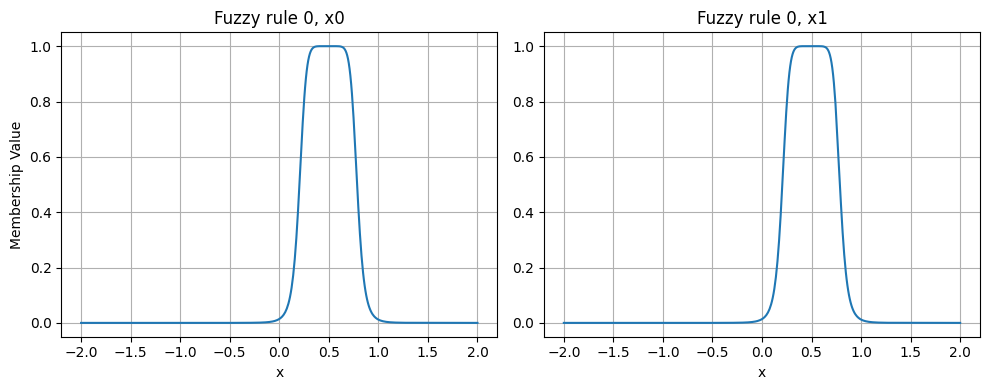

In [9]:
model.plot_premises()

### Hybrid Learning Algorithm

In [10]:
loss_fn = nn.functional.mse_loss
#loss_fn = nn.functional.binary_cross_entropy
#loss_fn = nn.functional.cross_entropy

optimizer = torch.optim.AdamW
params = {'lr': 0.001, 'weight_decay': 0.01}

early_stopping = EarlyStopping(patience=15, delta=0.01)

In [11]:
trainer = Hybrid_learning_algorithm(
    epochs=50,
    loss_function=loss_fn,
    optimizer=optimizer,
    optimizer_params=params,
    early_stopping=early_stopping
)

### SONFIS

In [12]:
Ngrow = 400
dGrow = 0.8
Nsplit = 200
eSplit = 0.5
Nvanish = 60
lVanish = 3

max_iterations = 40

anfis_trainer = trainer

validation = 0.2
sonfis_early_stopping = EarlyStopping(patience=5, delta=0.01)
last_training_iteration = True

In [13]:
sonfis = rule_reduced_SONFIS(
    Ngrow=Ngrow,
    dGrow=dGrow,
    Nsplit=Nsplit,
    eSplit=eSplit,
    Nvanish=Nvanish,
    lVanish=lVanish,
    max_iterations=max_iterations,
    ANFIStrainer=anfis_trainer,
    validation=validation,
    early_stopping=sonfis_early_stopping,
    last_training_iteration=last_training_iteration
)

In [14]:
%time sonfis(model, train_loader, verbose=True)

Iteration:  0/40 - loss: 3.765064 - validation loss: 3.348111
 -> Fuzzy rules: 2

Iteration:  1/40 - loss: 2.232046 - validation loss: 1.967320
 -> Fuzzy rules: 3

Iteration:  2/40 - loss: 0.967099 - validation loss: 0.933046
 -> Fuzzy rules: 4

Iteration:  3/40 - loss: 0.603643 - validation loss: 0.572223
 -> Fuzzy rules: 4

Iteration:  4/40 - loss: 0.288930 - validation loss: 0.288690
 -> Fuzzy rules: 5

Iteration:  5/40 - loss: 0.234264 - validation loss: 0.230843
 -> Fuzzy rules: 6

Iteration:  6/40 - loss: 0.210386 - validation loss: 0.206878
 -> Fuzzy rules: 7

Iteration:  7/40 - loss: 0.166275 - validation loss: 0.163690
 -> Fuzzy rules: 8

Iteration:  8/40 - loss: 0.173274 - validation loss: 0.168901
 -> Fuzzy rules: 9

Iteration:  9/40 - loss: 0.158603 - validation loss: 0.157533
 -> Fuzzy rules: 9

Iteration: 10/40 - loss: 0.206074 - validation loss: 0.204060
 -> Fuzzy rules: 10

Iteration: 11/40 - loss: 0.194426 - validation loss: 0.192340
 -> Fuzzy rules: 11

Early stopping

In [15]:
x_test = test_loader.dataset.tensors[0]
y_test = test_loader.dataset.tensors[1]

test_measures = get_measures(model, x_test, y_test)

for measure in test_measures:
    print(measure + ':', test_measures[measure])

MSE: 0.019212237917944335
RMSE: 0.13860821735360546
MAE: 0.09679526704207823
R2: 0.9948279126765216
MAPE: 12.329751657295512


In [16]:
train_measures = get_measures(model, x_train, y_train)

for measure in train_measures:
    print(measure + ':', train_measures[measure])

MSE: 0.027972882722460384
RMSE: 0.1672509573140327
MAE: 0.12812893230505795
R2: 0.9923112985674617
MAPE: 1.5306038045083956
